In [109]:
import numpy as np

In [110]:
rng = np.random.default_rng()
data_size = 16

In [111]:
X = [rng.uniform(-10, 10, size=data_size)][0]
print(X)

[ 8.72939991 -0.10936076  9.54597902  1.79628005  9.81005546  2.32632384
  4.8376522   4.62538601 -7.29834372 -6.64509025  4.42057029 -3.57700473
 -9.02979992  5.6793149  -9.670785   -6.31135424]


In [112]:
num_coefficients = rng.integers(low=1, high=6)
coefficients = rng.integers(
  low=-2, high=3, 
  size=num_coefficients)

In [113]:
from numpy.polynomial import Polynomial
poly = Polynomial(coefficients)

In [114]:
import math
y = poly(X)
noise = rng.normal(loc=0.0, scale=math.sqrt(abs(np.array(y).mean())), size=data_size)
y = y + noise
y = y.flatten()

In [115]:
print(y)

[135.14471963  11.40977288 161.62974357  -5.27024423 173.02386702
   4.68218069  18.49295667  31.79161241  95.68205094  96.91477524
  30.09073384  37.93684113 173.75201449  50.82271132 220.59979436
  82.67764422]


In [116]:
print(X)

[ 8.72939991 -0.10936076  9.54597902  1.79628005  9.81005546  2.32632384
  4.8376522   4.62538601 -7.29834372 -6.64509025  4.42057029 -3.57700473
 -9.02979992  5.6793149  -9.670785   -6.31135424]


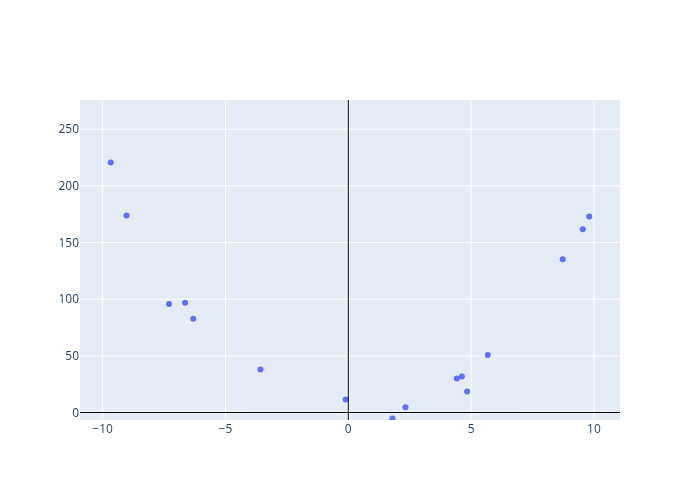

In [117]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter(x=X, y=y, mode='markers')])
fig.add_hline(y=0, line_color='black', line_width=1)
fig.add_vline(x=0, line_color='black', line_width=1)
fig.update_yaxes(range=[min(y) * 1.25, max(y) * 1.25])
fig.show(renderer="png")

In [118]:
# X = X.reshape(-1, 1)
# print(X)

In [119]:
# hyperparameters
k = 4

In [120]:
powers = np.arange(k)
Phi = X.reshape(-1, 1) ** powers
print(Phi)

[[ 1.00000000e+00  8.72939991e+00  7.62024228e+01  6.65201423e+02]
 [ 1.00000000e+00 -1.09360756e-01  1.19597750e-02 -1.30793004e-03]
 [ 1.00000000e+00  9.54597902e+00  9.11257154e+01  8.69884167e+02]
 [ 1.00000000e+00  1.79628005e+00  3.22662200e+00  5.79591672e+00]
 [ 1.00000000e+00  9.81005546e+00  9.62371882e+01  9.44092153e+02]
 [ 1.00000000e+00  2.32632384e+00  5.41178260e+00  1.25895589e+01]
 [ 1.00000000e+00  4.83765220e+00  2.34028788e+01  1.13214988e+02]
 [ 1.00000000e+00  4.62538601e+00  2.13941957e+01  9.89564137e+01]
 [ 1.00000000e+00 -7.29834372e+00  5.32658210e+01 -3.88752271e+02]
 [ 1.00000000e+00 -6.64509025e+00  4.41572244e+01 -2.93428741e+02]
 [ 1.00000000e+00  4.42057029e+00  1.95414417e+01  8.63843163e+01]
 [ 1.00000000e+00 -3.57700473e+00  1.27949629e+01 -4.57676428e+01]
 [ 1.00000000e+00 -9.02979992e+00  8.15372866e+01 -7.36265384e+02]
 [ 1.00000000e+00  5.67931490e+00  3.22546177e+01  1.83184131e+02]
 [ 1.00000000e+00 -9.67078500e+00  9.35240825e+01 -9.04451295e

In [121]:
y = y.reshape(-1, 1)

In [122]:
coeff_pred = (np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y).flatten()
print(coeff_pred)

[-4.50341245 -1.53783812  2.02805465 -0.00510939]


In [123]:
poly_pred = Polynomial(coeff_pred)
y_pred = poly_pred(X)
x_smooth, y_smooth = poly_pred.linspace(n=100, domain=[X.min(), X.max()])

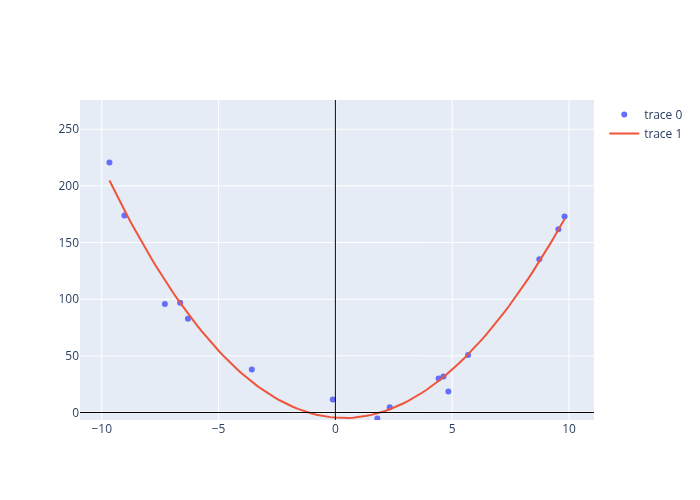

In [124]:
fig.add_trace(go.Scatter(x=x_smooth, y=y_smooth, mode='lines'))
fig.show(renderer="png")